# Bestand der Personenwagen nach Marke, Stadtquartier und Jahr, seit 2002
Datum: 07.02.2025

Dieser Datensatz beinhaltet die Anzahl Personenwagen der Stadt Zürich nach Automarke, Stadtquartier und Jahr seit 2002.

**Dataset auf PROD Datenkatalog**:  https://data.stadt-zuerich.ch/dataset/prd_ssz_fz_pw_bestand_marke_quartier_od2003

### Colab
Mit Colab kann das Jupyter-Notebook interaktiv im Browser gestartet werden. 

Klicke auf den Button:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DonGoginho/colab/blob/main/dogs/od2003_prd_ssz_fz_pw_bestand_marke_quartier_od2003.ipynb)



### Importiere die notwendigen Packages

In [147]:
#%pip install altair datetime folium geopandas io requests matplotlib numpy pandas seaborn plotly
!pip install altair==5.0.1 vl-convert-python

In [148]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

1) Klone das Github-Repo auf Colab. Sonst werden die Skripts nicht gelesen...

In [149]:
!git clone https://github.com/DonGoginho/colab.git


fatal: destination path 'colab' already exists and is not an empty directory.


2) Checke die Schreibrechte in den geklonten Verzeichnissen

In [150]:
!ls -l /content/colab
!ls -l /content/colab/dogs


Der Befehl "ls" ist entweder falsch geschrieben oder
konnte nicht gefunden werden.
Der Befehl "ls" ist entweder falsch geschrieben oder
konnte nicht gefunden werden.


3) Importiere die Skripts

In [151]:
import sys
sys.path.append('/content/colab/0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [152]:
#help(mypy_dv)
#help(mypy_dl)

In [153]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [154]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [155]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [156]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [157]:
package_name = "prd_ssz_fz_pw_bestand_marke_quartier_od2003"

In [158]:
data2betested = mypy_dl.load_data(
    status = 'prod'
    , data_source = 'dropzone'
    , package_name = package_name
    , dataset_name = "VER200OD2003"      
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:\\szh\ssz\applikationen\OGD_Dropzone\DWH\prd_ssz_fz_pw_bestand_marke_quartier_od2003\VER200OD2003.csv
data_source: dropzone


In [159]:
data2betested.head(4).T

,0,1,2,3
StichtagDat,2002-09-30,2002-09-30,2002-09-30,2002-09-30
StichtagDatJahr,2002-01-01 00:00:00,2002-01-01 00:00:00,2002-01-01 00:00:00,2002-01-01 00:00:00
FzMarkeLang,AMC,AMC,AMC,AMC
QuarLang,Alt-Wiedikon,Hirzenbach,Hottingen,Höngg
QuarCd,31,123,72,101
QuarSort,31,123,72,101
KreisLang,Kreis 3,Kreis 12,Kreis 7,Kreis 10
KreisCd,3,12,7,10
KreisSort,3,12,7,10
FzAnz,4,1,1,1


Berechne weitere Attribute falls notwendig

In [160]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDat                    object
StichtagDatJahr        datetime64[ns]
FzMarkeLang                    object
QuarLang                       object
QuarCd                          int64
QuarSort                        int64
KreisLang                      object
KreisCd                         int64
KreisSort                       int64
FzAnz                           int64
StichtagDatJahr_str            object
Jahr                   datetime64[ns]
Jahr_end               datetime64[ns]
Jahr_nbr                        int32
dtype: object

In [161]:
data2betested.head(2)

,StichtagDat,StichtagDatJahr,FzMarkeLang,QuarLang,QuarCd,QuarSort,KreisLang,KreisCd,KreisSort,FzAnz,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
48579,2024-09-30,2024-01-01,Zastava,Escher Wyss,52,52,Kreis 5,5,5,1,2024-01-01,2024-01-01,2024-12-31,2024
47268,2024-09-30,2024-01-01,Ford,Hirslanden,73,73,Kreis 7,7,7,36,2024-01-01,2024-01-01,2024-12-31,2024


Minimales und maximales Jahr im Datensatz

In [162]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 2002 und ein Maximumjahr von 2024


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [163]:
data2betested = data2betested.set_index("StichtagDatJahr") 
data2betested = data2betested.sort_index()

In [164]:
data2betested.index.year.unique()

Index([2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
       2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
      dtype='int32', name='StichtagDatJahr')

### Einfache Datentests

In [165]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48580 entries, 2002-01-01 to 2024-01-01
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   StichtagDat          48580 non-null  object        
 1   FzMarkeLang          48580 non-null  object        
 2   QuarLang             48580 non-null  object        
 3   QuarCd               48580 non-null  int64         
 4   QuarSort             48580 non-null  int64         
 5   KreisLang            48580 non-null  object        
 6   KreisCd              48580 non-null  int64         
 7   KreisSort            48580 non-null  int64         
 8   FzAnz                48580 non-null  int64         
 9   StichtagDatJahr_str  48580 non-null  object        
 10  Jahr                 48580 non-null  datetime64[ns]
 11  Jahr_end             48580 non-null  datetime64[ns]
 12  Jahr_nbr             48580 non-null  int32         
dtypes: datetime64[

In [166]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 48,580 rows (observations) and 13 columns (variables).
There seem to be 0 exact duplicates in the data.


### Pivotiere

In [167]:
pivoted_df = data2betested.pivot_table(
    index='Jahr',
    columns='FzMarkeLang',
    values='FzAnz',
    aggfunc='sum'
)

pivoted_df = pivoted_df.sort_values(by=pivoted_df.index[-1], axis=1, ascending=False)

# Sortieren der Zeilen (Jahre) in absteigender Reihenfolge
pivoted_df = pivoted_df.sort_index(ascending=False)

# Anzeigen des Ergebnisses
pivoted_df.head(8).T

Jahr,2024-01-01,2023-01-01,2022-01-01,2021-01-01,2020-01-01,2019-01-01,2018-01-01,2017-01-01
FzMarkeLang,,,,,,,,
Volkswagen,17744,18604,18843,19161,19082,18996,19528,19599
BMW,13395,13626,13644,13558,13453,13159,13067,12909
Mercedes Benz,13227,13011,12841,12836,12389,11747,11615,11379
Audi,10639,11076,11071,11225,11151,11144,11486,11575
Skoda,7270,7432,7198,7057,6853,6445,6229,5906
...,...,...,...,...,...,...,...,...
Toro,NaN,NaN,NaN,NaN,NaN,NaN,1,1
Toyo Kogyo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
UAZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [168]:
pivoted_df_diff = pivoted_df.sort_index(ascending=True).diff()
pivoted_df_diff.tail(5)

FzMarkeLang,Volkswagen,BMW,Mercedes Benz,Audi,Skoda,Toyota,Volvo,...,Tescar,Think,Toro,Toyo Kogyo,UAZ,Unbekannt,Weinsberg
Jahr,,,,,,,,,,,,,,,
2020-01-01,86,294,642,7,408,49,164,...,0,-2,NaN,NaN,NaN,-1,-13
2021-01-01,79,105,447,74,204,-16,89,...,0,0,NaN,NaN,NaN,2,-16
2022-01-01,-318,86,5,-154,141,-10,-104,...,-1,0,NaN,NaN,NaN,11,-3
2023-01-01,-239,-18,170,5,234,208,-43,...,0,NaN,NaN,NaN,NaN,6,-11
2024-01-01,-860,-231,216,-437,-162,-108,-238,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Top Marken des aktuellen Jahrs

In [169]:
#    .query('FzMarkeLang!="Rover"')\
agg_marke_years = data2betested\
    .groupby(['StichtagDatJahr','Jahr_nbr','FzMarkeLang']) \
    .agg(sum_FzAnz=('FzAnz', 'sum')) \
    .sort_values(['StichtagDatJahr','sum_FzAnz'], ascending=[False, False]) 
agg_marke_years.reset_index().head(5)

,StichtagDatJahr,Jahr_nbr,FzMarkeLang,sum_FzAnz
0,2024-01-01,2024,Volkswagen,17744
1,2024-01-01,2024,BMW,13395
2,2024-01-01,2024,Mercedes Benz,13227
3,2024-01-01,2024,Audi,10639
4,2024-01-01,2024,Skoda,7270


Mach eine Liste mit den Top15 Fahrzeugen im aktuellen Jahr

In [170]:
df_top_25 = agg_marke_years.reset_index().query('StichtagDatJahr == '+data_max_date).sort_values('sum_FzAnz', ascending=False).head(25)
df_top_5 = agg_marke_years.reset_index().query('StichtagDatJahr == '+data_max_date).sort_values('sum_FzAnz', ascending=False).head(5)
df_top_25.head(2)
#df_list_top_15_23 = top_15[['FzMarkeLang','sum_FzAnz']]
list_top_25_latest_year = df_top_25['FzMarkeLang'].tolist()
list_top_5_latest_year = df_top_5['FzMarkeLang'].tolist()

#list_top_25_latest_year


In [171]:
#list_top_25_latest_year

Wähle aus dem nach Jahr aggregierten Dataframe nur jene aus der Top25-Liste aus

In [172]:
#agg_marke_years.reset_index()

In [173]:
df_sel_top25_since2002 = agg_marke_years.reset_index().query('FzMarkeLang in @list_top_25_latest_year')
df_sel_top5_since2002 = agg_marke_years.reset_index().query('FzMarkeLang in @list_top_5_latest_year')
#df_sel_top25_since2002

In [174]:
df_sel_top25_since2002.head(2)

,StichtagDatJahr,Jahr_nbr,FzMarkeLang,sum_FzAnz
0,2024-01-01,2024,Volkswagen,17744
1,2024-01-01,2024,BMW,13395


In [175]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = df_sel_top25_since2002.reset_index().sort_values('FzMarkeLang', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_FzAnz:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "FzMarkeLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Top-25 Marken von "+data_max_date+", seit "+data_min_date
)
grafik1

alt.LayerChart(...)

#### Faced Grids

In [176]:
data2betested.columns


Index(['StichtagDat', 'FzMarkeLang', 'QuarLang', 'QuarCd', 'QuarSort', 'KreisLang', 'KreisCd',
       'KreisSort', 'FzAnz', 'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [177]:
myFG = data2betested.loc[data_min_date:data_max_date]\
    .query('FzMarkeLang in @list_top_5_latest_year')\
    .groupby(['StichtagDatJahr', 'KreisLang', 'KreisCd', 'KreisSort','FzMarkeLang']) \
    .agg(sum_FzAnz=('FzAnz', 'sum')) \
    .sort_values('KreisSort', ascending=True) 

myFG.reset_index().head(3)

,StichtagDatJahr,KreisLang,KreisCd,KreisSort,FzMarkeLang,sum_FzAnz
0,2002-01-01,Kreis 1,1,1,Audi,277
1,2013-01-01,Kreis 1,1,1,Volkswagen,669
2,2013-01-01,Kreis 1,1,1,Skoda,176


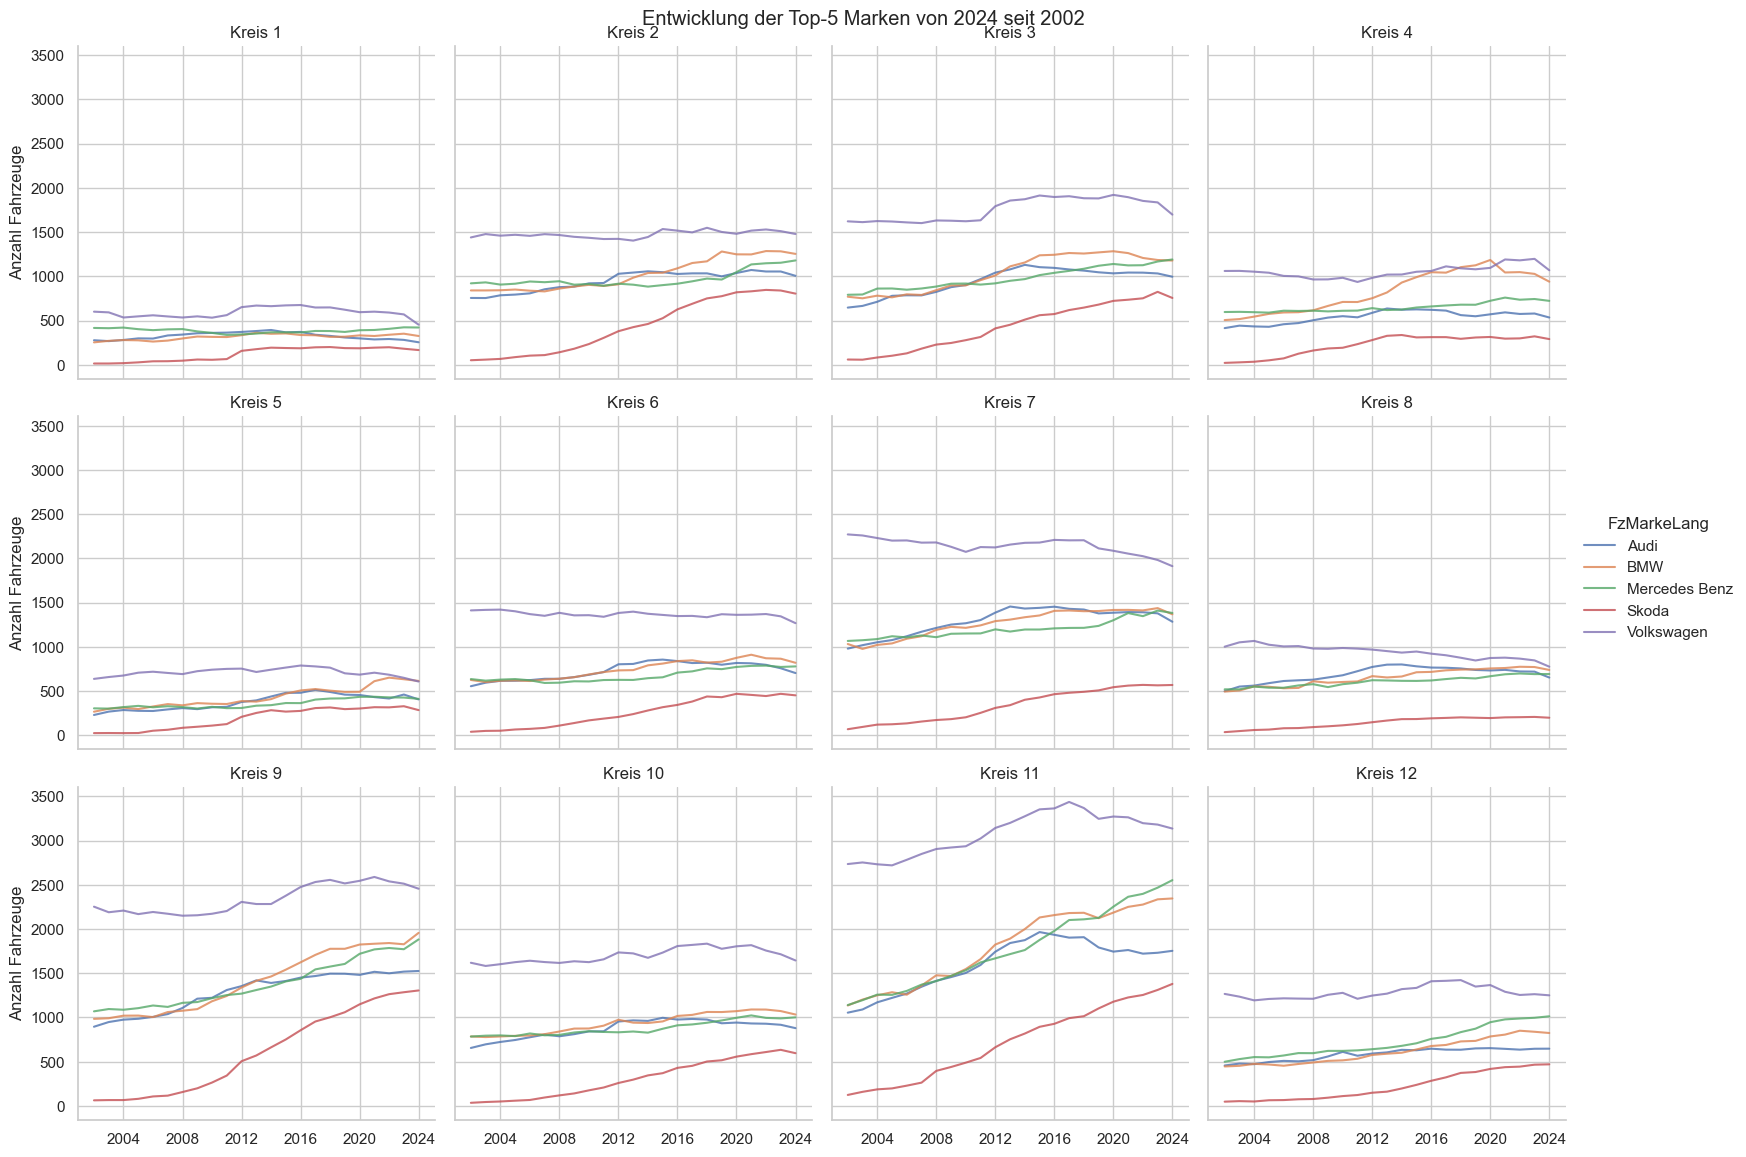

In [178]:
faced_grid = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('KreisSort', ascending=True)
    ,col = "KreisLang"
    ,hue = "FzMarkeLang"
    ,col_wrap = 4
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "sum_FzAnz"
    ,ylabel= "Anzahl Fahrzeuge"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Entwicklung der Top-5 Marken von "+data_max_date+' seit '+data_min_date
)
faced_grid

In [179]:
myFG1 = data2betested.loc[data_min_date:data_max_date]\
    .query('FzMarkeLang in @list_top_25_latest_year')\
    .groupby(['StichtagDatJahr', 'KreisLang', 'KreisCd', 'KreisSort','FzMarkeLang']) \
    .agg(sum_FzAnz=('FzAnz', 'sum')) \
    .sort_values('KreisSort', ascending=True) 

myFG1.reset_index().head(3)

,StichtagDatJahr,KreisLang,KreisCd,KreisSort,FzMarkeLang,sum_FzAnz
0,2002-01-01,Kreis 1,1,1,Alfa Romeo,67
1,2020-01-01,Kreis 1,1,1,Renault,66
2,2020-01-01,Kreis 1,1,1,Porsche,172


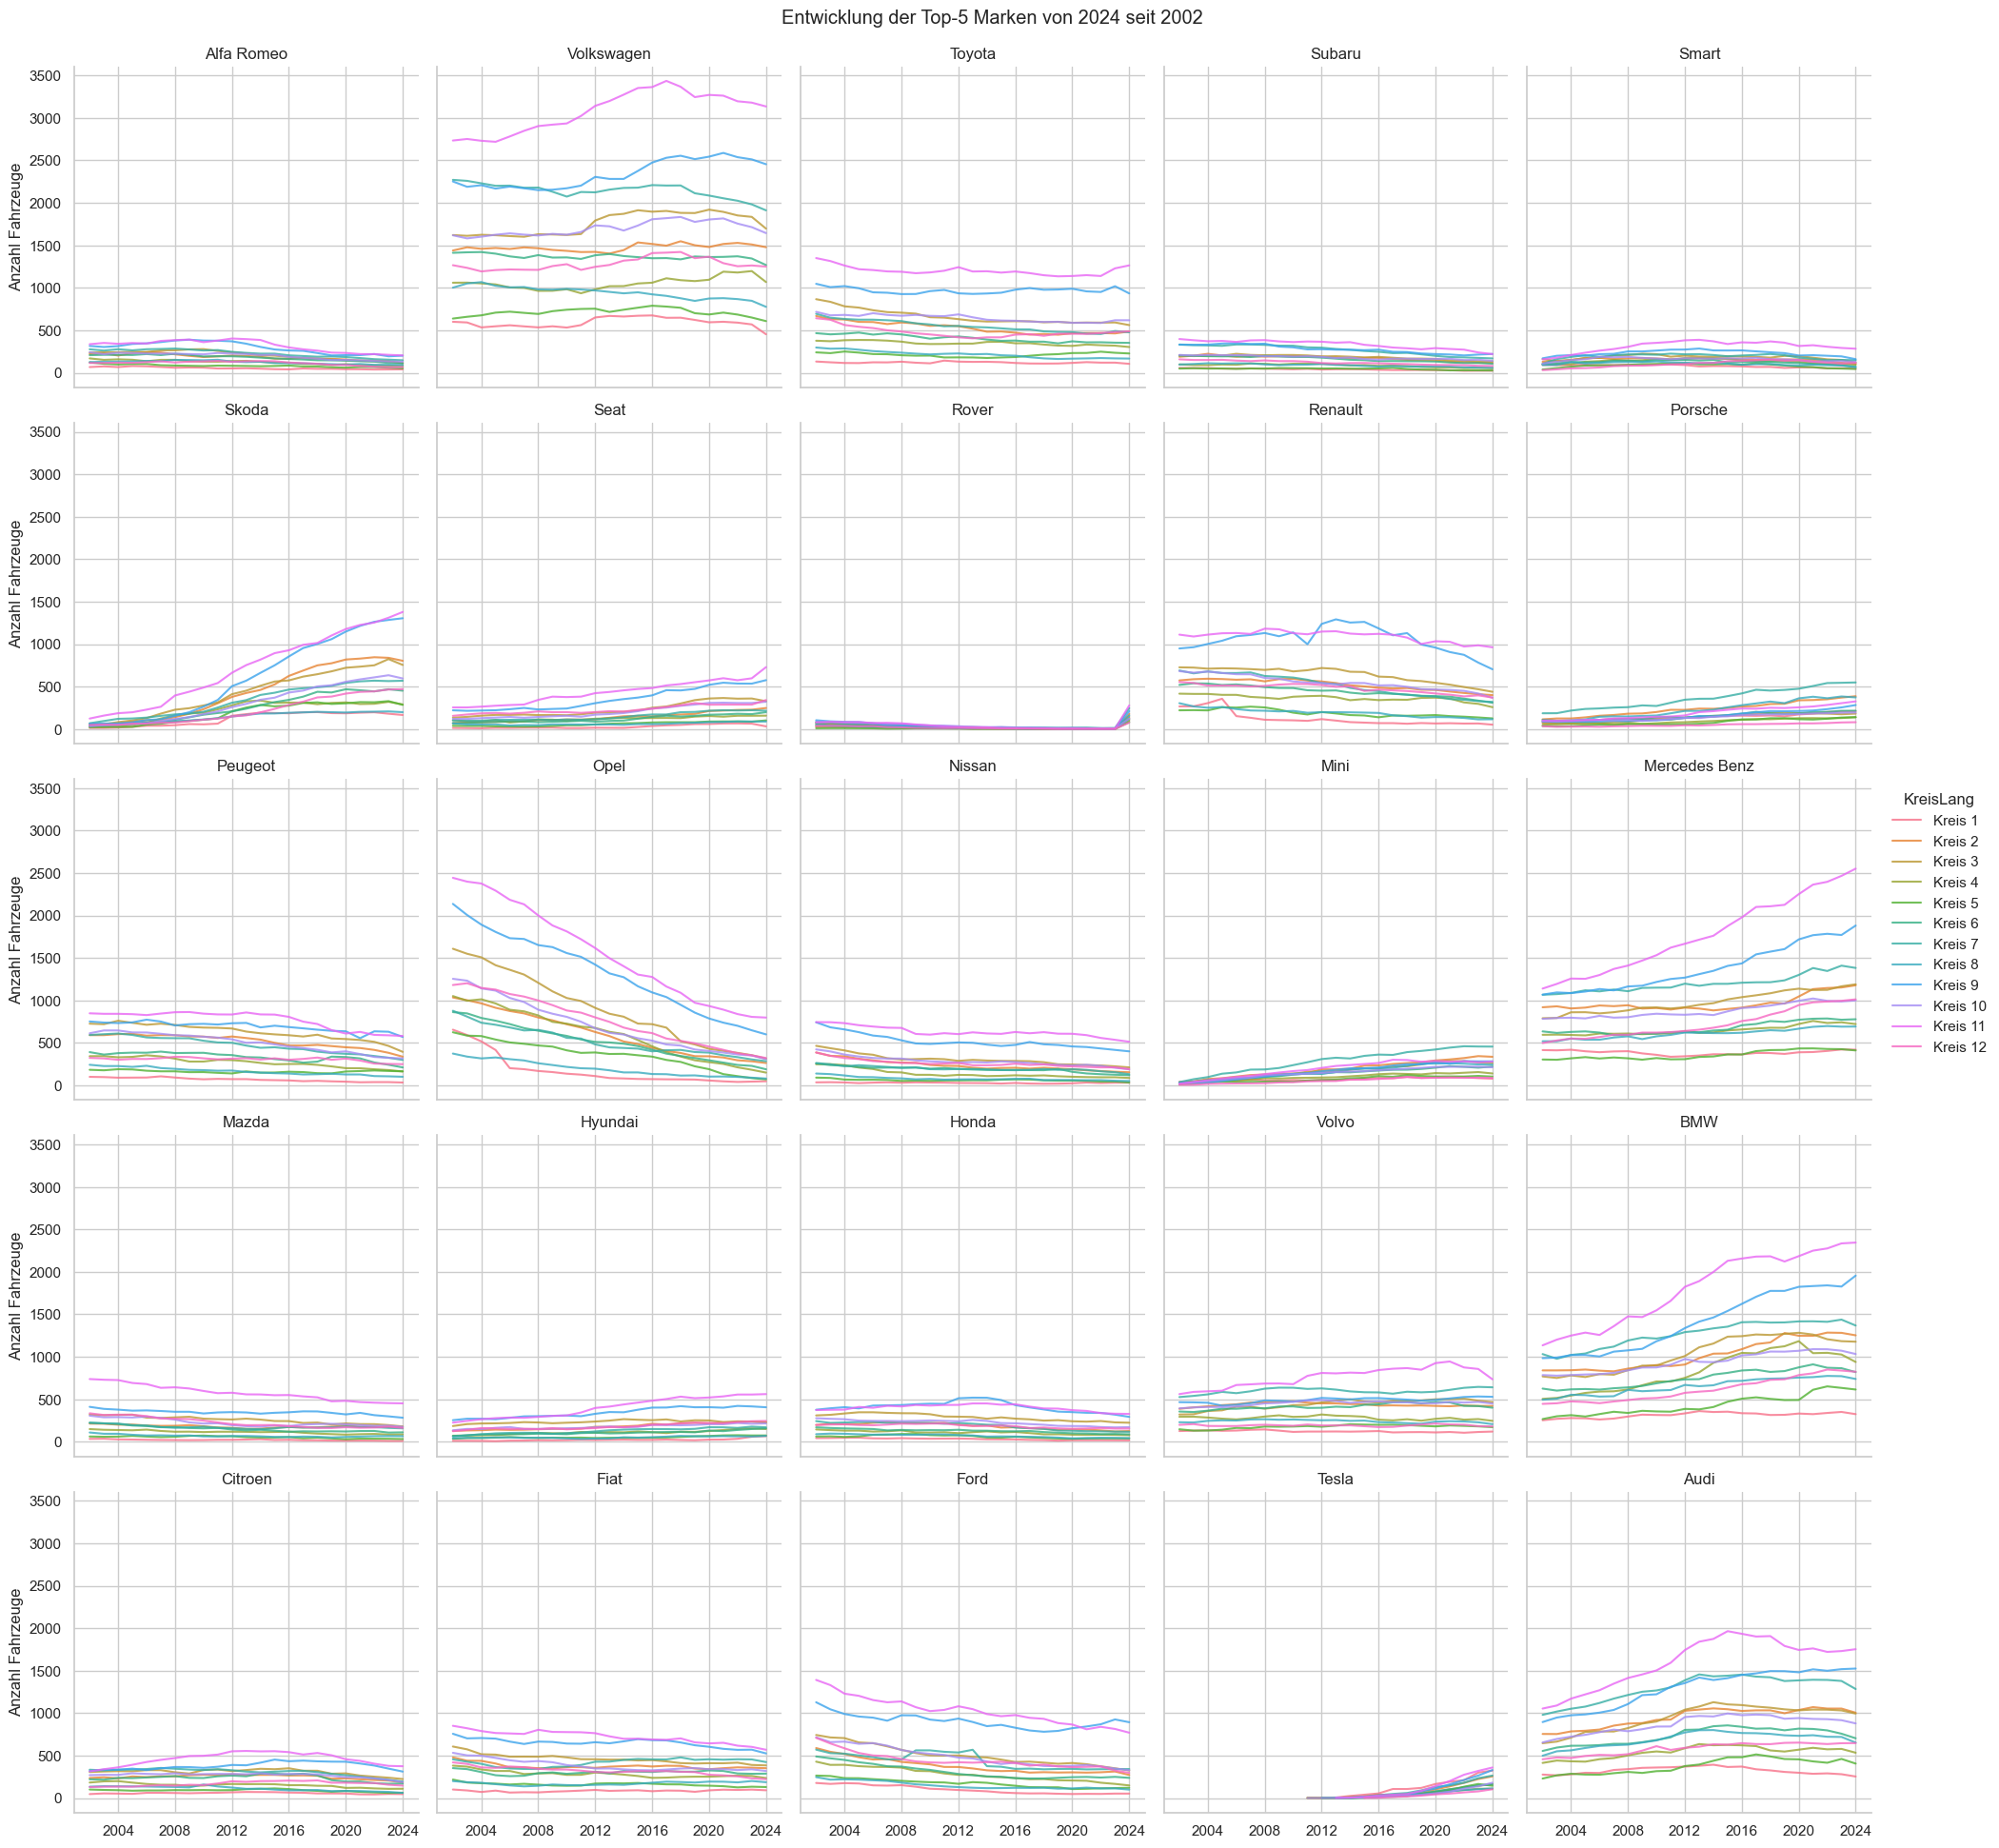

In [180]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG1.reset_index().sort_values('KreisSort', ascending=True)
    ,col = "FzMarkeLang"
    ,hue = "KreisLang"
    ,col_wrap = 5
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "sum_FzAnz"
    ,ylabel= "Anzahl Fahrzeuge"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Entwicklung der Top-5 Marken von "+data_max_date+' seit '+data_min_date
)
faced_grid1

In [183]:
myFG3 = data2betested.loc[data_min_date:data_max_date]\
    .query('FzMarkeLang in @list_top_25_latest_year')\
    .groupby(['StichtagDatJahr', 'Jahr_nbr','FzMarkeLang']) \
    .agg(sum_FzAnz=('FzAnz', 'sum')) \
    .sort_values('Jahr_nbr', ascending=True) 

myFG3.reset_index().head(3)

,StichtagDatJahr,Jahr_nbr,FzMarkeLang,sum_FzAnz
0,2002-01-01,2002,Alfa Romeo,2431
1,2002-01-01,2002,Volvo,4007
2,2002-01-01,2002,Volkswagen,17913


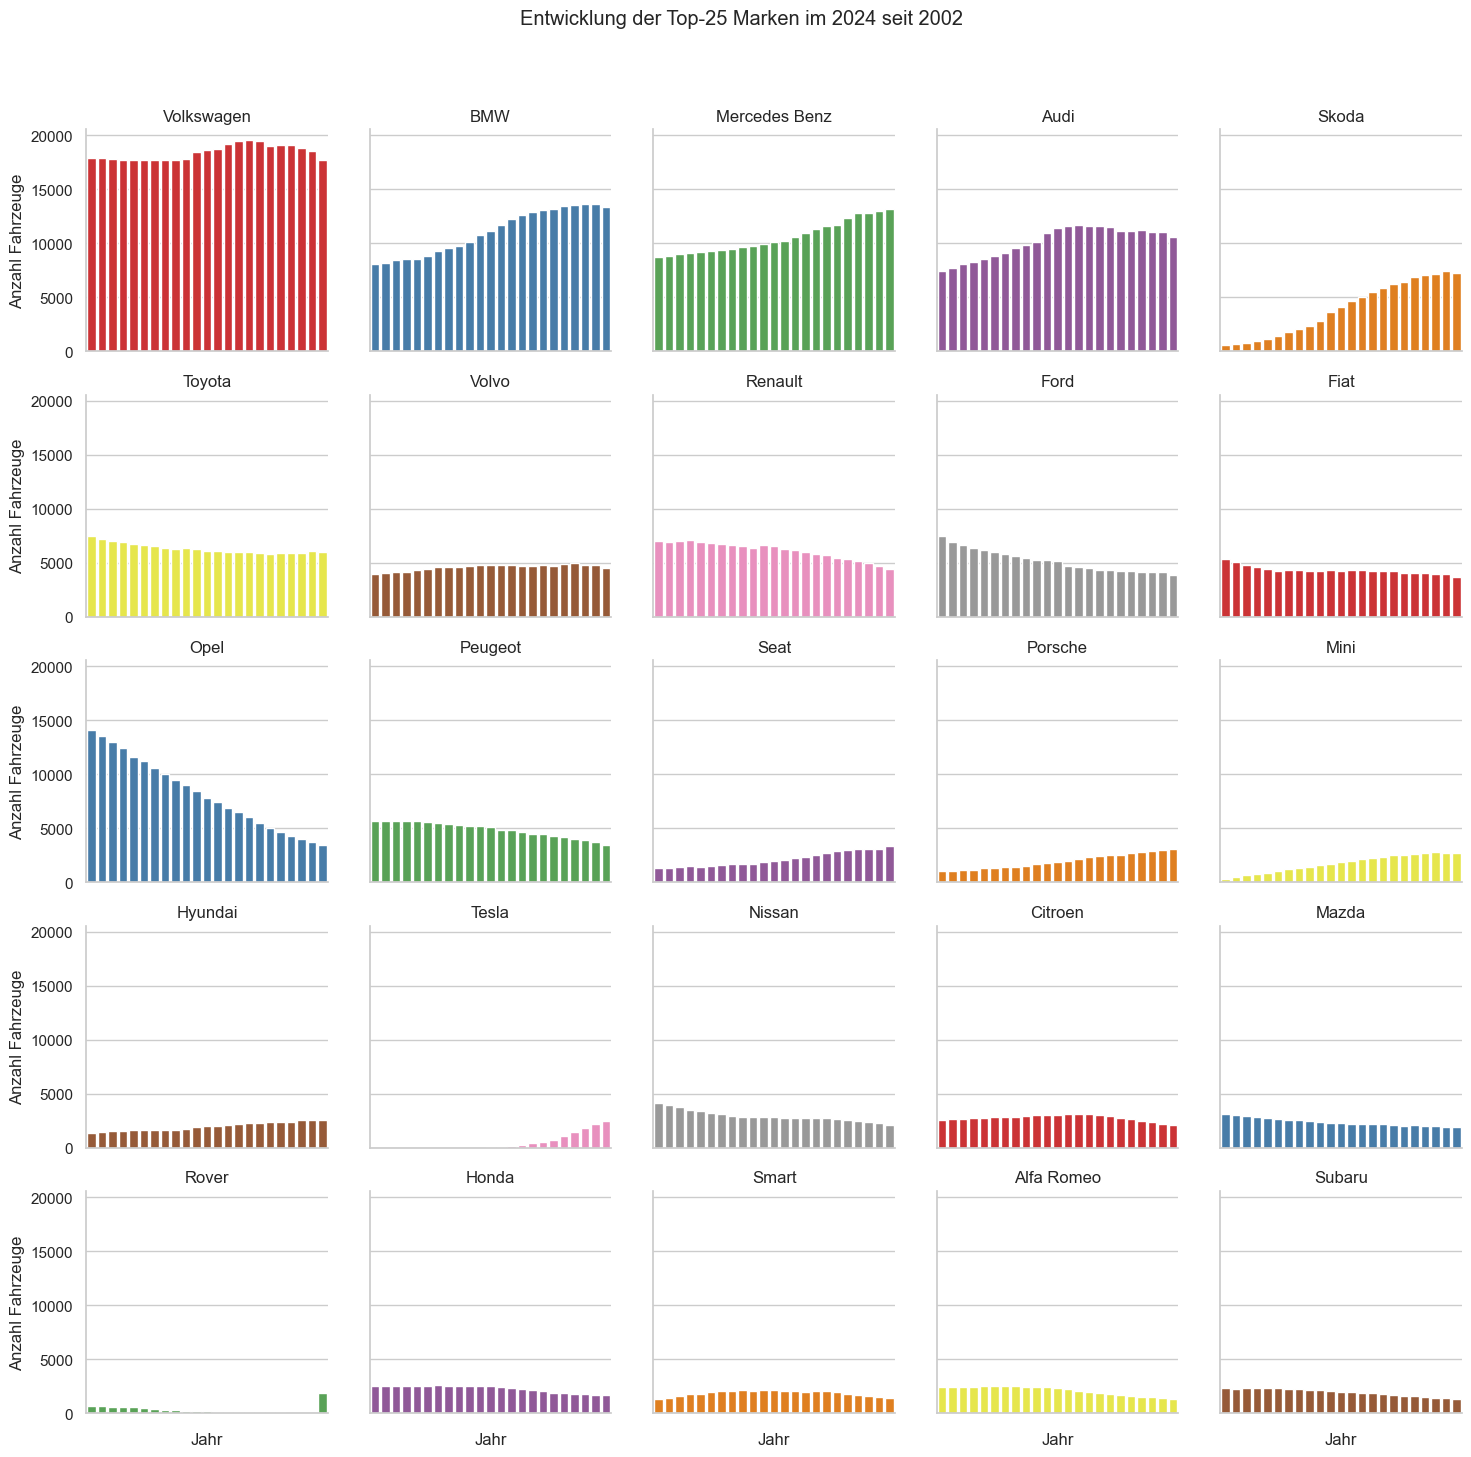

In [184]:
# Beispiel-Daten
data = myFG3.reset_index().sort_values(['Jahr_nbr','sum_FzAnz'], ascending=[False, False])

# Reihenfolge der Jahre festlegen (sortiert)
jahr_order = sorted(data['Jahr_nbr'].unique())
#print(jahr_order)

# FacetGrid erstellen
facet_grid = sns.FacetGrid(
    data=data,
    col="FzMarkeLang",
    hue="FzMarkeLang",
    col_wrap=5,
    height=3,
    palette="Set1"
)

# Barplot auf jedes Facet anwenden
facet_grid.map(
    sns.barplot,
    "Jahr_nbr",  # x-Achse
    "sum_FzAnz", # y-Achse
    order=jahr_order  
)

# Titel und Achsenbeschriftungen hinzufügen
facet_grid.set_axis_labels("Jahr", "Anzahl Fahrzeuge")
facet_grid.set_titles("{col_name}")
facet_grid.set_xticklabels(rotation=45)
# Nach facet_grid.map()

#facet_grid.add_legend()

# Layout anpassen und anzeigen
plt.subplots_adjust(top=0.9)
facet_grid.fig.suptitle("Entwicklung der Top-25 Marken im " + data_max_date + ' seit ' + data_min_date)

plt.show()

#### Treemaps

**Funktion zum einfärben**

*Comment: Muss ich noch als Funktion umsetzen*

In [192]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [194]:
df_top_35_alltime = agg_marken.reset_index().sort_values('sum_FzAnz', ascending=False).head(25)
df_top_5_alltime  = agg_marken.reset_index().sort_values('sum_FzAnz', ascending=False).head(5)
df_top_35_alltime.head(2)
#df_list_top_15_23 = top_15[['FzMarkeLang','sum_FzAnz']]
list_top_35_alltime = df_top_35_alltime['FzMarkeLang'].tolist()
list_top_5_alltime = df_top_5_alltime['FzMarkeLang'].tolist()

In [195]:
# Extrahiere die Top-Fahrzeugmarken
#attr2becolored = data2betested['FzMarkeLang'].unique().tolist()
attr2becolored = list_top_35_alltime
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(attr2becolored):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Volkswagen': '#0017BF', 'BMW': '#0072D7', 'Mercedes Benz': '#00A5D2', 'Audi': '#5E359A', 'Opel': '#BA0062', 'Toyota': '#DA5563', 'Renault': '#00615D', 'Ford': '#00770F', 'Peugeot': '#7BA600', 'Volvo': '#7B4100', 'Fiat': '#DC5500', 'Skoda': '#DA9C00', 'Nissan': '#5D4BFE', 'Citroen': '#4AA9FF', 'Mazda': '#55FFFF', 'Honda': '#986AD5', 'Seat': '#FC4C99', 'Alfa Romeo': '#FF919A', 'Hyundai': '#349894', 'Porsche': '#44B14A', 'Subaru': '#B7E14E', 'Smart': '#B97624', 'Mini': '#FF7231', 'Mitsubishi': '#FFD736', 'Saab': '#3431DE'}


In [196]:
myTreemapAgg = data2betested.loc[data_max_date]\
    .groupby(['StichtagDatJahr', 'FzMarkeLang','QuarLang', 'QuarCd', 'QuarSort', 'KreisLang', 'KreisCd', 'KreisSort']) \
    .agg(sum_FzAnz=('FzAnz', 'sum')) \
    .sort_values('sum_FzAnz', ascending=False) 

##### Fahrzeugmarken nach Kreis, Quartier

In [197]:
#data=data2betested.loc[(data2betested.index.year == 2004)| (data2betested.index.year == 2014) | (data2betested.index.year == 2024)].query("FzAnz>50")
treeMap0 = mypy_dv.plot_px_treemap(
    data=data2betested.loc[(data2betested.index.year == 2004)| (data2betested.index.year == 2024)].query("FzAnz>50")
    ,levels=['Jahr_nbr', 'FzMarkeLang','KreisLang', 'QuarLang']
    ,values="FzAnz"
    ,color="FzMarkeLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Fahrzeugbestände nach Marke, Stadtkreis und Stadtquartier, 2004 vs "+data_max_date
)
treeMap0

path: [<plotly.express._special_inputs.Constant object at 0x000001DFCC1B5710>, 'Jahr_nbr', 'FzMarkeLang', 'KreisLang', 'QuarLang']
Typ von path: <class 'list'>


In [200]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=data2betested.loc[(data2betested.index.year == 2004)| (data2betested.index.year == 2014) | (data2betested.index.year == 2024)].query("FzAnz>20")
    ,levels=['QuarLang','FzMarkeLang','Jahr_nbr', ]
    ,values="FzAnz"
    ,color="FzMarkeLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Fahrzeugbestände nach Stadtquartier, Marke und Jahr (2004, 2014 und "+data_max_date +")"
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x000001DFC7B6AD90>, 'QuarLang', 'FzMarkeLang', 'Jahr_nbr']
Typ von path: <class 'list'>
